In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

In [2]:
np.random.seed(4112345)

In [3]:
class MatchingMethods:
    def __init__(self, x1:np.ndarray, x2:np.ndarray, method:str=''):
        self.x1 = x1
        self.x2 = x2
        self.method = method
    
    def matching(self) -> float:
        return np.sum(np.minimum(self.x1, self.x2))
    
    def jaccard(self) -> float:
        _matching = self.matching()
        return 1.0 - (_matching / np.sum(np.maximum(self.x1, self.x2)))
    
    def dice(self) -> float:
        _matching = 2 * self.matching()
        return 1.0 - (_matching / (np.sum(self.x1) + np.sum(self.x2)))
    
    def overlap(self) -> float:
        _matching = self.matching()
        return 1 - (_matching / np.sum(self.x1) + np.sum(self.x2))
    
    def __call__(self, *args, **kwargs):
        allowed_methods:dict = {
            'matching':self.matching(),
            'jaccard':self.jaccard(),
            'dice':self.dice(),
            'overlap':self.overlap()
        }
        if self.method != '':
            return allowed_methods[self.method]

### Formas de usar MatchingMethods

In [4]:
x1:np.ndarray = np.array([1,2,3,4,5])
x2:np.ndarray = np.array([1,2,5,4,6])
mm = MatchingMethods(x1, x2, 'matching')
print(mm())
mm = MatchingMethods(x1, x2, 'jaccard')
print(mm())
mm = MatchingMethods(x1, x2, 'dice')
print(mm())
mm = MatchingMethods(x1, x2, 'overlap')
print(mm())
mm = MatchingMethods(x1, x2)
print(mm.matching(), mm.jaccard(), mm.dice(), mm.overlap())

15
0.16666666666666663
0.09090909090909094
-18.0
15 0.16666666666666663 0.09090909090909094 -18.0


### New version of matrix class

In [5]:
from ScOPE.matrix import Matrix as OldMatrix

In [6]:
class Matrix(OldMatrix):
    
    def __calc_matrix__(self, samples:np.ndarray) -> np.ndarray:
        distance_matrix:np.ndarray = np.zeros(shape=(len(samples), len(samples)-1),
                                              dtype=np.float32)        
        for index_i, sample_i in enumerate(samples):
            current_x1:str = sample_i
            x1_compressed_len:float= self.compressor(sequence=current_x1)
            for index_j, sample_j in enumerate(samples):
                if index_j == index_i:
                    continue
                current_x2:str = sample_j
                x2_compressed_len:float = self.compressor(sequence=current_x2)
                x1x2:str = self.join(current_x1, current_x2)
                x1x2_compressed_len:float = self.compressor(sequence=x1x2)
                index_j:int = index_j-1 if index_j >= index_i else index_j
                current_distance = self.distance(x1=x1_compressed_len,
                                                 x2=x2_compressed_len,
                                                 x1x2=x1x2_compressed_len)
                
                distance_matrix[index_i,index_j] = current_distance        
        return distance_matrix

    def get_matrix(self, sample, classes:np.ndarray) -> np.ndarray:
        
        classes:dict = {index:values for index, values in enumerate(classes)}
        matrix:np.ndarray = np.zeros(shape=(len(classes),
                                            len(classes[0])+1,
                                            len(classes[0])),
                                     dtype=np.float32)
        
        for class_ in classes:
            samples:np.ndarray = np.append(classes[class_], sample)
            matrix[class_,:,:] = self.__calc_matrix__(samples)
        return matrix

#### Ejemplo de uso de la clase matrix

In [7]:
from ScOPE import Compressor
from ScOPE import Distance

compressor = Compressor('gzip')
distance = Distance('ncd')
matrix = Matrix(compressor, distance, append_type='text_as_array')

class0 = ['Hola', 'Adios', 'Buenos dias']
class1 = ['Hello', 'Goodbye', 'Good morning']
sample = ['Hello']
print(matrix.get_matrix(sample, [class0, class1]))

[[[0.76       1.         0.64      ]
  [0.72       0.87096775 0.72      ]
  [0.9677419  0.9032258  1.        ]
  [0.6        0.64       0.9354839 ]]

 [[0.7037037  0.9375     0.36      ]
  [0.7407407  0.90625    0.7407407 ]
  [0.9375     0.90625    0.9375    ]
  [0.36       0.7037037  0.9375    ]]]


In [8]:
from ScOPE import Compressor
from ScOPE import Distance

compressor = Compressor('gzip')
distance = Distance('ncd')
matrix = Matrix(compressor, distance, sep=' ', append_type='text')

class0 = ['Hola', 'Adios', 'Buenos dias']
class1 = ['Hello', 'Goodbye', 'Good morning']
sample = 'Hello'
print(matrix.get_matrix(sample, [class0, class1]))

[[[0.24       0.38709676 0.24      ]
  [0.24       0.32258064 0.24      ]
  [0.38709676 0.38709676 0.38709676]
  [0.24       0.24       0.38709676]]

 [[0.2962963  0.40625    0.12      ]
  [0.2962963  0.34375    0.2962963 ]
  [0.40625    0.34375    0.40625   ]
  [0.12       0.2962963  0.40625   ]]]


In [11]:
from ScOPE import Compressor
from ScOPE import Distance

compressor = Compressor('gzip')
distance = Distance('ncd')
matrix = Matrix(compressor, distance, sep='-', append_type='text_as_array')

class0 = ['Hola', 'Adios', 'Buenos dias']
class1 = ['Hello', 'Goodbye', 'Good morning']
sample = 'Hello'
print(matrix.get_matrix(sample, [class0, class1]))

[[[0.76       1.         0.64      ]
  [0.72       0.87096775 0.72      ]
  [0.9677419  0.9032258  1.        ]
  [0.6        0.64       0.9354839 ]]

 [[0.7037037  0.9375     0.36      ]
  [0.7407407  0.90625    0.7407407 ]
  [0.9375     0.90625    0.9375    ]
  [0.36       0.7037037  0.9375    ]]]


### Ejemplo de uso de Matching + Matrix

In [12]:
SMILES_COLUMN:str = 'smiles'
LABEL_COLUMN:str = 'FDA_APPROVED'
FILE_PATH:str = 'clintox.csv'
dataF:pd.DataFrame = pd.read_csv(FILE_PATH)
dataF.head()

,smiles,FDA_APPROVED,CT_TOX
0,*C(=O)[C@H](CCCCNC(=O)OCCOC)NC(=O)OCCOC,1,0
1,[C@@H]1([C@@H]([C@@H]([C@H]([C@@H]([C@@H]1Cl)C...,1,0
2,[C@H]([C@@H]([C@@H](C(=O)[O-])O)O)([C@H](C(=O)...,1,0
3,[H]/[NH+]=C(/C1=CC(=O)/C(=C\C=c2ccc(=C([NH3+])...,1,0
4,[H]/[NH+]=C(\N)/c1ccc(cc1)OCCCCCOc2ccc(cc2)/C(...,1,0


In [13]:
X = dataF[SMILES_COLUMN].values
Y = dataF[LABEL_COLUMN].values
X, Y

(array(['*C(=O)[C@H](CCCCNC(=O)OCCOC)NC(=O)OCCOC',
        '[C@@H]1([C@@H]([C@@H]([C@H]([C@@H]([C@@H]1Cl)Cl)Cl)Cl)Cl)Cl',
        '[C@H]([C@@H]([C@@H](C(=O)[O-])O)O)([C@H](C(=O)[O-])O)O', ...,
        'O=[Zn]', 'OCl(=O)(=O)=O', 'S=[Se]=S'], dtype=object),
 array([1, 1, 1, ..., 1, 1, 1], dtype=int64))

In [14]:
def generate_samples(x:np.ndarray, y:np.ndarray, samples:int=5):
    classes:np.ndarray = np.unique(y)
    for index in range(len(x)):
        test_y:np.ndarray = y[index]
        test_x = x[index]
        kw_samples:list = []
        for classIndex in range(len(classes)):
            mask:np.ndarray = np.where(y == classes[classIndex])[0]
            while True:
                random_index:np.ndarray = np.random.choice(mask, size=samples, replace=True)
                if index not in random_index:
                    break
            kw_samples.append(x[random_index])
        yield test_x, kw_samples, test_y

### Gauss function

In [15]:
def gauss(x:np.ndarray) -> np.ndarray:
    sigma:float = 0.12
    return np.exp(-0.5 * np.square((x/sigma)))

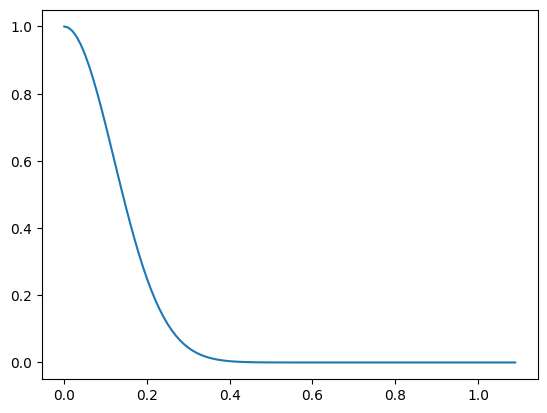

In [16]:
test = np.arange(0, 1.1, 0.01)
gauss_samples = gauss(test)
plt.plot(test, gauss_samples)
plt.show()

#### Gauss test

In [28]:
tests: list = generate_samples(X, Y, samples=10)

compressor = Compressor('bz2')
distance = Distance('ncd')
matrix = OldMatrix(compressor, distance, append_type='text_as_array', sep='')

all_y:list = []
all_pred:list = []

for test in tests:
    temp_x, kw_samples, test_y = test
    all_distances = gauss(matrix.get_matrix(temp_x, kw_samples))
    classification:np.ndarray = np.zeros(shape=(len(all_distances)), dtype=np.float32)
    for index, x in enumerate(all_distances):
        query:np.ndarray = x[-1]
        samples:np.ndarray = x[:-1]
        for index_s, sample in enumerate(samples):
            mm = MatchingMethods(query, sample)
            classification[index] += mm.dice()
    predicted_class = classification.argmin()
    all_y.append(test_y)
    all_pred.append(predicted_class)

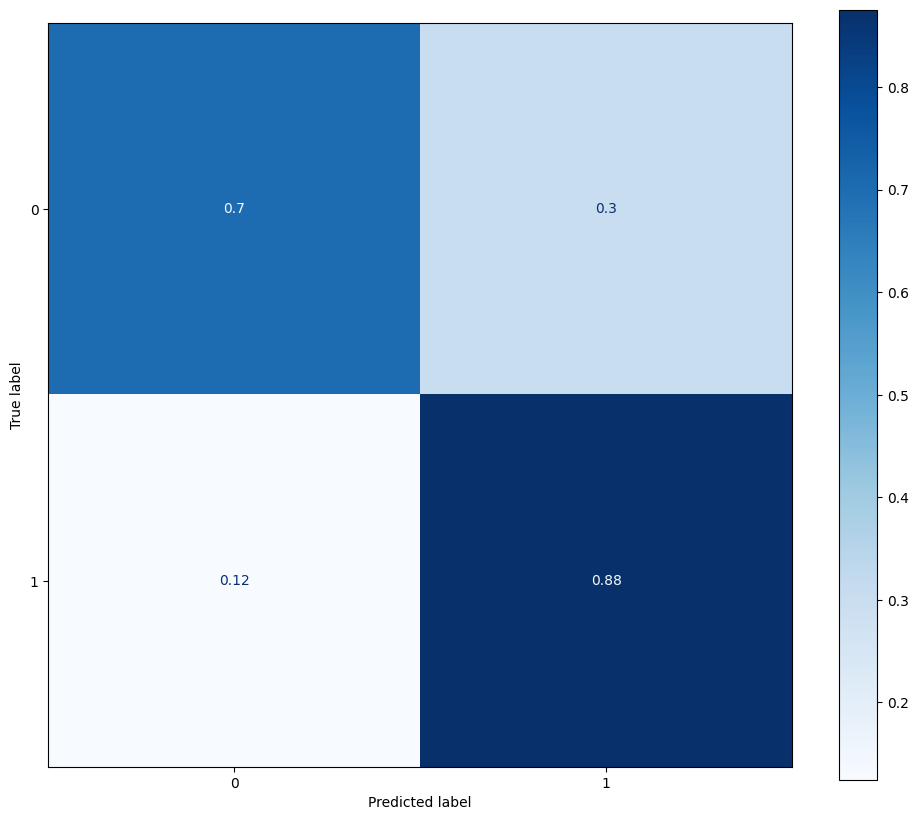

In [29]:
fig, ax = plt.subplots(figsize=(12,10))

disp = ConfusionMatrixDisplay.from_predictions(y_true=all_y,
                                               y_pred=all_pred,
                                               ax=ax,
                                               normalize='true',
                                               cmap='Blues')